100%|██████████| 100000/100000 [00:57<00:00, 1729.61it/s]


time cost 60.51177191734314 s


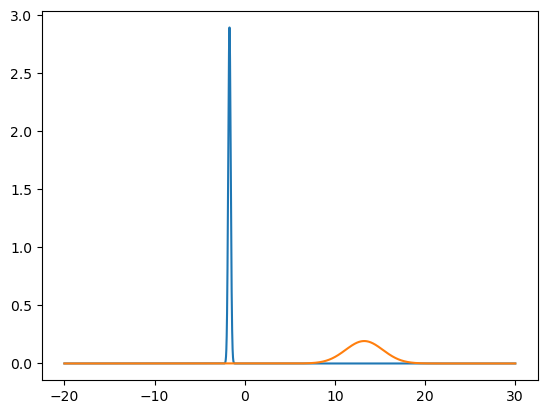

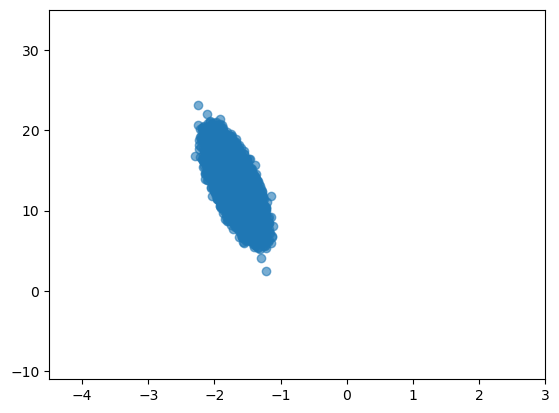

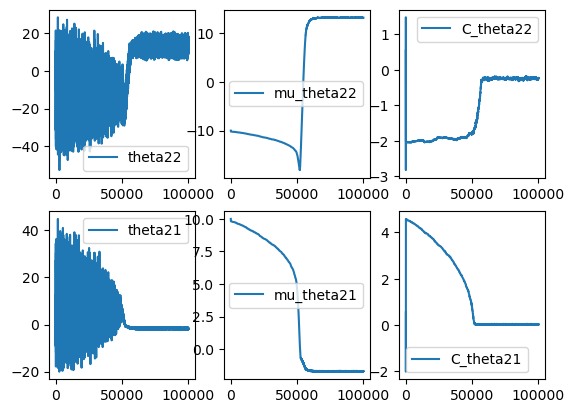

In [ ]:
# 132s/68s
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import scipy.stats as stats

np.random.seed(123456)
torch.manual_seed(7)

time_start=time.time()

Y11_np = np.array([7, 6, 10, 10, 1, 1, 10, 4, 35, 0, 10, 8, 4]).reshape((-1, 1))
Y11 = torch.tensor(Y11_np, dtype=torch.float64)
Y12_np = np.array([111, 71, 162, 188, 145, 215, 166, 37, 173, 143, 229, 696, 93]).reshape((-1, 1))
Y12 = torch.tensor(Y12_np, dtype=torch.float64)
Y21_np = np.array([16, 215, 362, 97, 76, 62, 710, 56, 133, 28, 62, 413, 194]).reshape((-1, 1))
Y21 = torch.tensor(Y21_np, dtype=torch.float64)
Y22_np = np.array([26983, 250930, 829348, 157775, 150467, 352445, 553066, 26751, 75815, 150302, 354993, 3683043, 507218]).reshape((-1, 1))
Y22 = torch.tensor(Y22_np, dtype=torch.float64)
Y22 = Y22/1000

def log_g_1(theta):
    A = torch.sum((- Y12 - 2) * torch.log(1 + torch.exp(- theta[0:13])) - (Y12 - Y11 + 1) * theta[0:13])
    return A


# iteration for theta1
K = 10000
rho = 0.95
epsilon = 1e-6
mu0 = -10
mu_np = np.array([mu0, mu0, mu0, mu0, mu0, mu0, mu0, mu0, mu0, mu0, mu0, mu0, mu0]).reshape((-1,1))
mu = torch.tensor(mu_np, dtype = torch.float64)
c0 = 1
C_diag = torch.tensor([c0, c0, c0, c0, c0, c0, c0, c0, c0, c0, c0, c0, c0], dtype = torch.float64)
C = torch.diag(C_diag)

E_g_mu = torch.zeros([13,1], dtype=torch.float64)
E_delta_mu = torch.zeros([13,1], dtype=torch.float64)
E_g_C = torch.ones([13,13], dtype=torch.float64) * 0.01
E_delta_C = torch.ones([13,13], dtype=torch.float64) * 0.01

theta1_history = np.zeros((13,K))
mu1_history = np.zeros((13,K))
C1_history = np.zeros((13,13,K))

def delta(C):
    D = torch.diag(1 / C.diag())
    return D


for t in tqdm(range(K)):
    z = np.random.multivariate_normal(np.zeros([13]), np.eye(13))
    z = torch.tensor(z).reshape((-1, 1))
    theta = (torch.mm(C, z) + mu).clone().detach().requires_grad_(True)
    gradient = log_g_1(theta)
    gradient.backward()


    g_mu = theta.grad
    E_g_mu = rho * E_g_mu + (1 - rho) * torch.mul(g_mu, g_mu)
    delta_mu = (torch.sqrt(E_delta_mu + epsilon) / torch.sqrt(E_g_mu + epsilon)) * g_mu
    E_delta_mu = rho * E_delta_mu + (1 - rho) * torch.mul(delta_mu, delta_mu)
    mu = mu + delta_mu

    g_C = torch.mm(theta.grad, z.transpose(0,1)) + delta(C)
    E_g_C = rho * E_g_C + (1 - rho) * torch.mul(g_C, g_C)
    delta_C = (torch.sqrt(E_delta_C + epsilon) / torch.sqrt(E_g_C + epsilon)) * g_C
    delta_C = torch.tril(delta_C)
    E_delta_C = rho * E_delta_C + (1 - rho) * torch.mul(delta_C, delta_C)
    C = C + delta_C

    theta1_history[:, t] = theta.detach().numpy().squeeze()
    mu1_history[:, t] = mu.squeeze()
    C1_history[:,:, t] = C.squeeze()



q_mu_1 = mu
q_C_1 = C


def log_g(theta):
    A = torch.sum((- Y12 - 2) * torch.log(1 + torch.exp(- theta[0:13])) - (Y12 - Y11 + 1) * theta[0:13])
    B = torch.sum(- torch.exp(theta[13] + theta[14]/(1 + torch.exp(-theta[0:13])) + torch.log(Y22)) +
                  Y21 * (theta[13] + theta[14]/(1 + torch.exp(-theta[0:13])) + torch.log(Y22)))
    C1 = (- theta[13] ** 2 - theta[14] ** 2)/2000
    return A + B + C1


# iteration for theta2
K2 = 100000
rho = 0.95
epsilon = 1e-6
mu0 = -10
mu_np = np.array([mu0, mu0, mu0, mu0, mu0, mu0, mu0, mu0, mu0, mu0, mu0, mu0, mu0, 10, -10]).reshape((-1,1))
mu = torch.tensor(mu_np, dtype = torch.float64)
c0 = 1
C_diag = torch.tensor([c0, c0, c0, c0, c0, c0, c0, c0, c0, c0, c0, c0, c0, 0.1, 0.1], dtype = torch.float64)
C = torch.diag(C_diag)

E_g_mu = torch.zeros([15,1], dtype=torch.float64)
E_delta_mu = torch.zeros([15,1], dtype=torch.float64)
E_g_C = torch.ones([15,15], dtype=torch.float64) * 0.01
E_delta_C = torch.ones([15,15], dtype=torch.float64) * 0.01

theta_history = np.zeros((15,K2))
mu_history = np.zeros((15,K2))
C_history = np.zeros((15,15,K2))



for t in tqdm(range(K2)):
    z = np.random.multivariate_normal(np.zeros([15]), np.eye(15))
    z = torch.tensor(z).reshape((-1, 1))
    theta = (torch.mm(C, z) + mu).clone().detach().requires_grad_(True)
    gradient = log_g(theta)
    gradient.backward()

    g_mu = theta.grad
    E_g_mu = rho * E_g_mu + (1 - rho) * torch.mul(g_mu, g_mu)
    delta_mu = (torch.sqrt(E_delta_mu + epsilon) / torch.sqrt(E_g_mu + epsilon)) * g_mu
    E_delta_mu = rho * E_delta_mu + (1 - rho) * torch.mul(delta_mu, delta_mu)
    mu = mu + delta_mu
    mu[0:13] = q_mu_1

    g_C = torch.mm(theta.grad, z.transpose(0,1)) + delta(C)
    E_g_C = rho * E_g_C + (1 - rho) * torch.mul(g_C, g_C)
    delta_C = (torch.sqrt(E_delta_C + epsilon) / torch.sqrt(E_g_C + epsilon)) * g_C
    delta_C = torch.tril(delta_C)
    E_delta_C = rho * E_delta_C + (1 - rho) * torch.mul(delta_C, delta_C)
    C = C + delta_C
    C[0:13,0:13] = q_C_1

    theta_history[:, t] = theta.detach().numpy().squeeze()
    mu_history[:, t] = mu.squeeze()
    C_history[:,:, t] = C.squeeze()



time_end=time.time()
print('time cost',time_end-time_start,'s')

V = torch.mm(C, C.transpose(0,1))
x = np.linspace(-20, 30, 10000)
q21 = stats.norm.pdf(x, mu[13].numpy(), np.sqrt(V[13,13]))
q22 = stats.norm.pdf(x, mu[14].numpy(), np.sqrt(V[14,14]))
plt.plot(x,q21, label = 'theta21')
plt.plot(x,q22, label = 'theta22')
plt.show()


s = np.random.multivariate_normal(mu[13:].squeeze(), V[13:,13:], 100000)
plt.scatter(s[:,0], s[:,1], alpha=0.6)
plt.xlim(-4.5,3)
plt.ylim(-11,35)
plt.show()
#np.save('mu_cut.npy',mu.numpy())
#np.save('V_cut.npy',V.numpy())
aver_mu = np.mean(mu_history[:, -10000:],1)
aver_C = np.mean(C_history[:,:, -10000:],2)
aver_V = np.matmul(aver_C, np.transpose(aver_C))
#np.save("aver_mu_cut.npy",aver_mu)
#np.save("aver_V_cut.npy",aver_V)

fig, axes = plt.subplots(2, 3)
axes[0, 0].plot(theta_history[14,:], label='theta22')
axes[0, 0].legend()
axes[0, 1].plot(mu_history[14, :], label='mu_theta22')
axes[0, 1].legend()
axes[0, 2].plot(C_history[14, 14,:], label='C_theta22')
axes[0, 2].legend()
axes[1, 0].plot(theta_history[13,:], label='theta21')
axes[1, 0].legend()
axes[1, 1].plot(mu_history[13, :], label='mu_theta21')
axes[1, 1].legend()
axes[1, 2].plot(C_history[13,13, :], label='C_theta21')
axes[1, 2].legend()
plt.show()


In [2]:
import pandas as pd
import pyreadr
import os
from pathlib import Path
import io, contextlib, warnings
base_dir = os.getcwd()
outdir = Path(base_dir) / "downstream"
outdir.mkdir(parents=True, exist_ok=True)
rds_path  = outdir / f"theta2_samples_Gaussian_VA.rds"
samples = s
samples_df = pd.DataFrame(samples, columns=[f"Dim{i+1}" for i in range(samples.shape[1])])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        pyreadr.write_rds(str(rds_path), samples_df)